In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta

In [52]:
def load_data(path):
    return pd.read_csv(path, index_col="datetime", parse_dates=True)

dbtc = load_data(path='../data/binance_BTC_USDT_2020_2026_15m.csv')
deth = load_data(path='../data/binance_ETH_USDT_2020_2026_15m.csv')

In [53]:
dbtc.head(2)

,open,high,low,close,volume
datetime,,,,,
2020-01-01 00:00:00,7195.24,7196.25,7178.20,7180.97,202.942868
2020-01-01 00:15:00,7180.97,7186.40,7175.47,7178.45,128.242654


In [54]:
deth.head(2)

,open,high,low,close,volume
datetime,,,,,
2020-01-01 00:00:00,129.16,129.19,128.69,128.91,1883.57914
2020-01-01 00:15:00,128.91,129.05,128.68,128.78,3686.07368


In [55]:
dbtc.describe()

,open,high,low,close,volume
count,218184.000000,218184.000000,218184.000000,218184.000000,218184.000000
mean,48269.079729,48361.212619,48174.172300,48269.372076,750.951847
std,31426.763787,31469.138723,31383.316385,31426.678355,1193.893552
min,3888.650000,4240.750000,3782.130000,3882.220000,0.000000
25%,22806.710000,22860.465000,22748.967500,22807.185000,184.914792
50%,41581.030000,41664.805000,41493.045000,41581.515000,371.802918
75%,67156.135000,67276.285000,67038.387500,67156.280000,793.048049
max,126011.180000,126199.630000,125648.010000,126011.180000,40371.405060


In [56]:
deth.describe()

,open,high,low,close,volume
count,218184.000000,218184.000000,218184.000000,218184.000000,218184.000000
mean,2172.081587,2177.738267,2166.192239,2172.090473,6554.762699
std,1161.217932,1164.088817,1158.196347,1161.209693,8344.604775
min,88.440000,97.660000,86.000000,88.350000,0.000000
25%,1533.010000,1537.925000,1528.232500,1533.025000,2218.039125
50%,2085.085000,2090.000000,2079.995000,2085.090000,4044.849550
75%,3072.795000,3081.727500,3063.130000,3072.812500,7669.443210
max,4942.980000,4956.780000,4933.850000,4942.980000,256455.462500


In [57]:
def plot_price(data):
    plt.plot(data)
    plt.title("Biểu đồ giá Close") 
    plt.xlabel("Thời gian")   
    plt.ylabel("Giá")         
    plt.grid(True)        
    plt.show() 

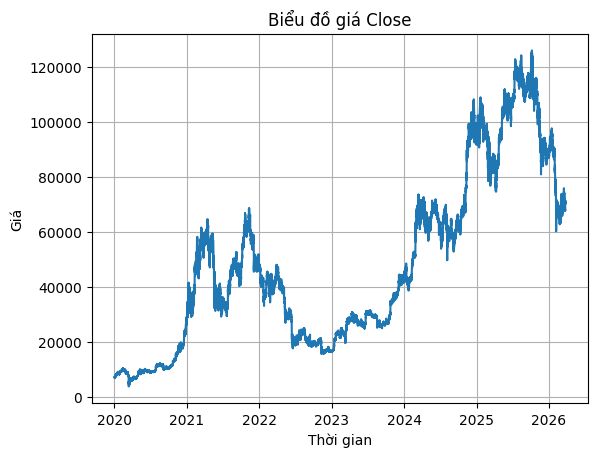

In [58]:
plot_price(dbtc.loc[:, "close"])

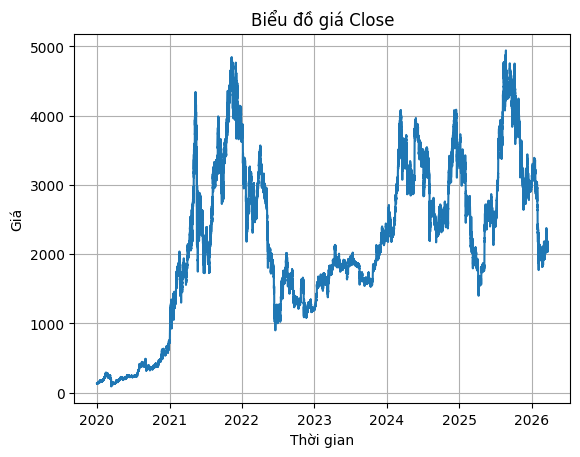

In [59]:
plot_price(deth.loc[:, "close"])

In [64]:
def pre_process(df):
    data = df.copy()
    
    EPSILON = 1e-8
    delta = data.index.to_series().diff()
    delta_time = delta.dt.total_seconds() / (60 * 15)
    delta_time = delta_time.fillna(1).astype(int)
    data['log_time_gap'] = np.log(delta_time)

    # 1. Temporal Features
    hours = data.index.hour
    day_of_week = data.index.dayofweek
    data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    data['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7)
    data['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7)

    # 2. Multi-horizon Momentum
    horizons = [1, 3, 5, 15, 60]
    for h in horizons:
        data[f'log_ret_{h}'] = np.log(data['close'] / data['close'].shift(h))

    # 3. Volatility & Risk Representation
    data['volatility_4'] = data['log_ret_1'].rolling(window=4).std()
    
    volatility_horizons = [16, 96, 672]
    for h in volatility_horizons:
        data[f'volatility_{h}'] = data['log_ret_1'].rolling(window=h).std()
        data[f'volatility_{h}_ratio'] = data['volatility_4'] / (data[f'volatility_{h}'] + EPSILON)

    # Normalized Spread
    data['spread_hl_norm'] = np.log(data['high'] / (data['low'] + EPSILON)) / (data['volatility_4'] + EPSILON)

    # 4. Microstructure & Volume Dynamics
    typical_price = ta.TYPPRICE(data['high'], data['low'], data['close'])
    tp_vol = typical_price * data['volume']
    
    rolling_tp_vol = ta.SUM(tp_vol, timeperiod=20)
    rolling_vol = ta.SUM(data['volume'], timeperiod=20)
    
    vwap_20 = rolling_tp_vol / (rolling_vol + EPSILON)
    data['dist_vwap_20'] = (data['close'] - vwap_20) / (vwap_20 + EPSILON)

    # 5. Signed Volume Pressure
    direction = np.sign(data['log_ret_1'].fillna(0))
    log_signed_volume = np.log(1 + data['volume']) * direction

    window_z = 96
    # Sử dụng biến local để tính mean và std
    mean_vol = ta.SMA(log_signed_volume, timeperiod=window_z)
    std_vol = ta.STDDEV(log_signed_volume, timeperiod=window_z, nbdev=1)

    # 2. Chỉ đưa những kết quả quan trọng vào DataFrame
    signed_vol_zscore = (log_signed_volume - mean_vol) / (std_vol + EPSILON)
    data['final_feature_ma'] = ta.SMA(signed_vol_zscore, timeperiod=20)
    data = data.dropna()
    return data

In [65]:
pdbtc = pre_process(dbtc)
include = pdbtc.columns.to_list()
exclude = ["open", "high", "low", "close", "volume"]
include = [x if x not in exclude else '' for x in include]
k = []
for x in include:
    if x != '':
        k.append(x)
k
pdbtc.loc[:, k].describe().to_csv('btc_statistics.csv')